# SI-26 Urdu OCR Project — Week 3 (v2)
## Expanding the Dataset (1,000+ Images) and Building a PyTorch `Dataset` Class + `DataLoader`

**Student:** Qandeel Asim
**Student ID:** 2023-BS-AI-037
**Programme:** Code Saviours ML/AI Internship — Batch SI-26
**Project:** Urdu OCR (Optical Character Recognition) Tool
**Week:** 3 of 5

---

### What changed from your original Week 3
Your original notebook proved the pipeline worked end-to-end on ~246 images, but used
**TrOCR's built-in English tokenizer** (`processor.tokenizer`) to encode Urdu labels.
That tokenizer is byte-level BPE trained on English text — it *can* technically
round-trip any UTF-8 text (which is why your Step 2 match check passed), but for Urdu
it breaks every character into multiple meaningless sub-byte tokens, making it far
harder for the decoder to learn real Urdu patterns. This is very likely a bigger
contributor to weak generalization than dataset size alone.

| # | Change | Where | Why |
|---|--------|-------|-----|
| 1 | `PROJECT_DIR` now points at the **Week 1 (v2) dataset** (1,000-2,000+ images) | Step 0 | Your Week 1 (v2) notebook builds a much bigger, more varied dataset in a new folder |
| 2 | `TARGET` raised 200 → 1,000 | Step 1 | Matches the new dataset's real scale |
| 3 | **Custom `UrduCharTokenizer`** replaces TrOCR's English tokenizer for labels | Step 2 | Character-level Urdu tokens instead of meaningless byte fragments — the single biggest fix here |
| 4 | **Data augmentation** (rotation, brightness/contrast, blur) applied to training rows only | Step 2 | Simulates real-world photo variation, directly targets the "works on training images, fails on new ones" problem |
| 5 | `max_length` raised 128 → 300 | Step 2 | Week 1 (v2)'s book-paragraph images have longer text than the original dataset |

Steps 0, 1, 1b, 1c, 3, and 4 keep the same structure and logic as your original
notebook — only the pieces above changed.

---
## Step 0 — Setup: Mount Google Drive and Locate the Project Folder

`drive.mount()` connects this Colab session to Google Drive so that all files under
`/content/drive/MyDrive/...` become readable/writable, exactly as if they were local
files.

**Change 1:** `PROJECT_DIR` now points at `Urdu_OCR_Project_v2` — the folder your
Week 1 (v2) notebook created — instead of the original `SI26_Urdu_OCR` folder.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# This is the root folder for the Week 1 (v2) dataset (1,000-2,000+ images).
PROJECT_DIR = '/content/drive/MyDrive/Urdu_OCR_Project_v2'

os.chdir(PROJECT_DIR)

print('Current working directory:', os.getcwd())
print('Top-level contents of the project folder:', os.listdir(PROJECT_DIR))

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/Urdu_OCR_Project_v2
Top-level contents of the project folder: ['data', 'week2_gap_analysis.csv', 'week2_word_recovery_rate.png', 'week2_text_length_by_source.png', 'labels.csv', 'fonts', 'corpus']


### Install/Upgrade Required Libraries

In [2]:
# transformers  -> provides ViTImageProcessor (image side) used to prepare model inputs
# torch         -> PyTorch, used for the Dataset/DataLoader classes and tensors
# torchvision   -> provides the data augmentation transforms
# pillow (PIL)  -> used to open and convert images
# pandas        -> used to read and manipulate labels.csv
!pip install -q transformers torch torchvision pillow pandas

### Reproducibility — Fix All Random Seeds

Setting a single seed for every source of randomness (Python's `random`, and
later PyTorch) makes the train/test split, the augmentation pipeline, and any
downstream training in Week 4 reproducible. Without this, re-running the
notebook can silently shuffle which images end up in `train` vs `test`,
making accuracy numbers hard to compare across runs.

In [3]:
import random

SEED = 42
random.seed(SEED)

print(f'Global random seed set to {SEED} for reproducible splits/results.')

Global random seed set to 42 for reproducible splits/results.


---
## Step 1 — Verify the Dataset Has 1,000+ Images

**Change 2:** `TARGET` raised from 200 to 1,000, to match the real scale of the
Week 1 (v2) dataset.

In [4]:
import pandas as pd


def find_file(root_dir, filename):
    """
    Walk through every folder inside root_dir and return the full path
    of the first file whose name matches `filename`.
    Returns None if the file is not found anywhere.
    followlinks=True makes sure Google Drive shortcuts/symlinked folders
    are also searched, not just regular folders.
    """
    for root, dirs, files in os.walk(root_dir, followlinks=True):
        if filename in files:
            return os.path.join(root, filename)
    return None


# Search for both possible label files anywhere inside the project folder.
LABELS_CSV = find_file(PROJECT_DIR, 'labels.csv')
PROCESSED_LABELS_CSV = find_file(PROJECT_DIR, 'processed_labels.csv')

if LABELS_CSV is None:
    raise FileNotFoundError(
        f'labels.csv could not be found anywhere inside {PROJECT_DIR}. '
        'Run the Week 1 (v2) and Week 2 (v2) notebooks first.'
    )

print('Found labels.csv at:', LABELS_CSV)
print('Found processed_labels.csv at:', PROCESSED_LABELS_CSV if PROCESSED_LABELS_CSV else 'not found (that is fine, we will use labels.csv)')

if PROCESSED_LABELS_CSV:
    LABELS_CSV = PROCESSED_LABELS_CSV

labels_df = pd.read_csv(LABELS_CSV)
current_count = len(labels_df)
TARGET = 1000   # was 200

print(f'\nTotal labeled images: {current_count}')
print(f'Target for Week 3 (v2): {TARGET}+ images')

if current_count >= TARGET:
    print(f'Requirement met: {current_count} >= {TARGET}. Step 1 is complete.')
else:
    print(f'Only {current_count} images found — {TARGET - current_count} more are needed before Step 2.')

Found labels.csv at: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
Found processed_labels.csv at: not found (that is fine, we will use labels.csv)

Total labeled images: 3128
Target for Week 3 (v2): 1000+ images
Requirement met: 3128 >= 1000. Step 1 is complete.


### Inspecting Dataset Composition

In [5]:
print('Image count by source:')
print(labels_df['source'].value_counts())

print('\nImage count by train/test split:')
print(labels_df['split'].value_counts(dropna=False))

Image count by source:
source
augmented_blur          618
synthetic               604
augmented_brightness    598
augmented_rotation      596
utrset_real             400
signboards_synthetic    162
books_synthetic         150
Name: count, dtype: int64

Image count by train/test split:
split
train    2502
test      626
Name: count, dtype: int64


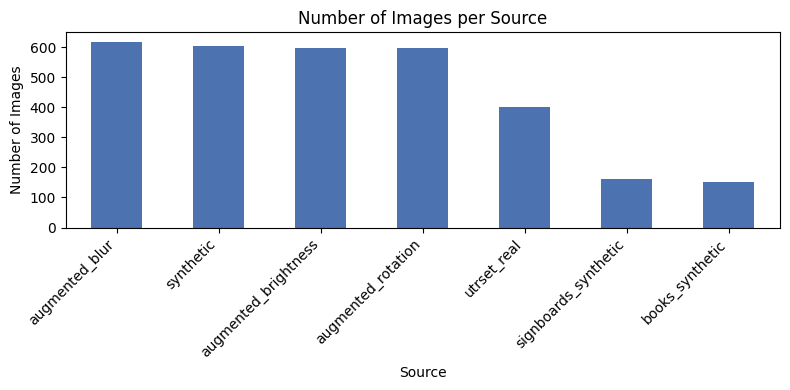

In [6]:
import matplotlib.pyplot as plt

source_counts = labels_df['source'].value_counts()

plt.figure(figsize=(8, 4))
source_counts.plot(kind='bar', color='#4C72B0')
plt.title('Number of Images per Source')
plt.xlabel('Source')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 1c — Fix Missing `split` Values

Unchanged from the original — some rows can lack a `split` value if they were added
after the original train/test split was created. This assigns any such rows 80/20.

In [7]:
missing_split_mask = labels_df['split'].isna()
num_missing = missing_split_mask.sum()
print(f'Rows with a missing split value: {num_missing}')

if num_missing > 0:
    missing_rows = labels_df[missing_split_mask].sample(frac=1, random_state=42)
    cutoff = int(0.8 * len(missing_rows))

    train_fill_idx = missing_rows.index[:cutoff]
    test_fill_idx = missing_rows.index[cutoff:]

    labels_df.loc[train_fill_idx, 'split'] = 'train'
    labels_df.loc[test_fill_idx, 'split'] = 'test'

    print(f'Assigned {len(train_fill_idx)} rows to train, {len(test_fill_idx)} rows to test.')

    labels_df.to_csv(LABELS_CSV, index=False)
    print(f'Corrected labels.csv saved back to: {LABELS_CSV}')
else:
    print('No missing split values found — nothing to fix.')

print('\nUpdated split counts:')
print(labels_df['split'].value_counts(dropna=False))
print(f"Total: {len(labels_df)} (should now equal train + test with no NaN remaining)")

Rows with a missing split value: 0
No missing split values found — nothing to fix.

Updated split counts:
split
train    2502
test      626
Name: count, dtype: int64
Total: 3128 (should now equal train + test with no NaN remaining)


---
## Step 1b — Resolve and Validate Every Image Path

Unchanged from the original — builds a filename index across the whole project
folder, then resolves each `labels.csv` path against it (handles files that moved or
got renamed).

In [8]:
file_index = {}
for root, dirs, files in os.walk(PROJECT_DIR, followlinks=True):
    for f in files:
        file_index.setdefault(f, os.path.join(root, f))

print(f'Indexed {len(file_index)} files across the project folder.')

Indexed 3538 files across the project folder.


In [9]:
def resolve_path(relative_path):
    """
    Try to resolve a path written in labels.csv to a real file on disk.
    Step 1: try the path exactly as written (relative to PROJECT_DIR).
    Step 2: if that fails, look up the file by its name only, using file_index.
    Returns None if the file cannot be found by either method.
    """
    direct_path = os.path.join(PROJECT_DIR, relative_path)
    if os.path.exists(direct_path):
        return direct_path

    filename_only = os.path.basename(relative_path)
    return file_index.get(filename_only)


image_column = 'processed_image' if 'processed_image' in labels_df.columns else 'image'
print(f'Using column "{image_column}" as the image path source.')

labels_df['resolved_path'] = labels_df[image_column].apply(resolve_path)

missing_mask = labels_df['resolved_path'].isna()
print(f'\nTotal rows: {len(labels_df)}')
print(f'Successfully resolved: {(~missing_mask).sum()}')
print(f'Could not be found anywhere: {missing_mask.sum()}')

if missing_mask.sum() > 0:
    print(f'\n{missing_mask.sum()} entries could not be located and will be excluded from training.')
    labels_df = labels_df[~missing_mask].reset_index(drop=True)

print(f'\nFinal usable dataset size after path resolution: {len(labels_df)} images')

Using column "image" as the image path source.

Total rows: 3128
Successfully resolved: 3128
Could not be found anywhere: 0

Final usable dataset size after path resolution: 3128 images


### Data Quality Checks — Corrupt Images and Empty Labels

Two common sources of noisy training/misleading accuracy are:

1. **Unreadable image files** — present in `labels.csv` and resolved on disk,
   but corrupted or truncated so `PIL` cannot actually open them.
2. **Empty or missing text labels** — rows where `text` is blank, whitespace-only,
   or `NaN`, which would otherwise train the model to predict nothing.

Both are checked and removed here, before the tokenizer and `Dataset` are built.

In [10]:
from PIL import Image, UnidentifiedImageError

def is_image_readable(path):
    """Return True if PIL can open and fully load the image at `path`."""
    try:
        with Image.open(path) as img:
            img.verify()  # cheap structural check
        with Image.open(path) as img:
            img.convert('RGB')  # full decode check
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


readable_mask = labels_df['resolved_path'].apply(is_image_readable)
num_corrupt = (~readable_mask).sum()
if num_corrupt > 0:
    print(f'Removing {num_corrupt} row(s) with corrupt/unreadable image files.')
    labels_df = labels_df[readable_mask].reset_index(drop=True)
else:
    print('No corrupt/unreadable images found.')

empty_text_mask = labels_df['text'].isna() | (labels_df['text'].astype(str).str.strip() == '')
num_empty = empty_text_mask.sum()
if num_empty > 0:
    print(f'Removing {num_empty} row(s) with empty/missing text labels.')
    labels_df = labels_df[~empty_text_mask].reset_index(drop=True)
else:
    print('No empty/missing text labels found.')

print(f'\nDataset size after data quality checks: {len(labels_df)} images')

No corrupt/unreadable images found.
No empty/missing text labels found.

Dataset size after data quality checks: 3128 images


---
## Step 2 — Build the Urdu Character Tokenizer — **Change 3**

**This is the most important change in this notebook.** Instead of TrOCR's built-in
English tokenizer, this is a character-level tokenizer built directly from the Urdu
text in your dataset. Every distinct Urdu character gets its own token ID, so the
decoder learns real Urdu character patterns instead of arbitrary byte fragments.

In [11]:
class UrduCharTokenizer:
    def __init__(self, texts, max_length=300):
        chars = set()
        for t in texts:
            chars.update(str(t))
        self.chars = sorted(chars)
        specials = ["<pad>", "<bos>", "<eos>", "<unk>"]
        self.vocab = {tok: i for i, tok in enumerate(specials)}
        for ch in self.chars:
            self.vocab[ch] = len(self.vocab)
        self.inv_vocab = {i: tok for tok, i in self.vocab.items()}
        self.pad_token_id = self.vocab["<pad>"]
        self.bos_token_id = self.vocab["<bos>"]
        self.eos_token_id = self.vocab["<eos>"]
        self.unk_token_id = self.vocab["<unk>"]
        self.max_length = max_length

    def __len__(self):
        return len(self.vocab)

    def encode(self, text, max_length=None, padding='max_length'):
        max_length = max_length or self.max_length
        ids = [self.bos_token_id] + [self.vocab.get(ch, self.unk_token_id) for ch in str(text)] + [self.eos_token_id]
        ids = ids[:max_length]
        if padding == 'max_length':
            ids = ids + [self.pad_token_id] * (max_length - len(ids))
        return ids

    def decode(self, ids, skip_special_tokens=True):
        out = []
        for i in ids:
            i = int(i)
            if skip_special_tokens and i in (self.pad_token_id, self.bos_token_id, self.eos_token_id):
                continue
            out.append(self.inv_vocab.get(i, ""))
        return "".join(out)


MAX_LEN = 300   # was 128 -- Week 1 (v2)'s book-paragraph images need more room
urdu_tokenizer = UrduCharTokenizer(labels_df['text'].tolist(), max_length=MAX_LEN)

print('Urdu character vocabulary size:', len(urdu_tokenizer))

longest = labels_df['text'].str.len().max()
print(f'Longest label in dataset: {longest} characters (MAX_LEN={MAX_LEN} must stay above this)')

# Round-trip sanity check
sample_text = labels_df['text'].iloc[0]
ids = urdu_tokenizer.encode(sample_text)
back = urdu_tokenizer.decode(ids)
print('\nOriginal :', sample_text)
print('Round-trip:', back)
print('Match:', sample_text.strip() == back.strip())

Urdu character vocabulary size: 125
Longest label in dataset: 245 characters (MAX_LEN=300 must stay above this)

Original : مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ببر علی انیس اور مرزا سلامت علی دبیر ہیں
Round-trip: مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ببر علی انیس اور مرزا سلامت علی دبیر ہیں
Match: True


### Save the Tokenizer Vocabulary for Week 4

The character-to-id mapping built above must stay identical between this
notebook and the Week 4 training/inference notebooks — if `UrduCharTokenizer`
is ever rebuilt from a different slice of text, character ids can shift and
silently mismatch a model trained on the old mapping. Saving the vocabulary
to disk lets Week 4 load the exact same tokenizer instead of reconstructing it.

In [12]:
import json

tokenizer_path = os.path.join(PROJECT_DIR, 'urdu_tokenizer_vocab.json')

with open(tokenizer_path, 'w', encoding='utf-8') as f:
    json.dump({'vocab': urdu_tokenizer.vocab, 'max_length': urdu_tokenizer.max_length}, f, ensure_ascii=False, indent=2)

print(f'Tokenizer vocabulary saved to: {tokenizer_path}')
print(f'Vocabulary size: {len(urdu_tokenizer)} | max_length: {urdu_tokenizer.max_length}')
print('Load it in Week 4 with: json.load(open(tokenizer_path, encoding="utf-8"))')

Tokenizer vocabulary saved to: /content/drive/MyDrive/Urdu_OCR_Project_v2/urdu_tokenizer_vocab.json
Vocabulary size: 125 | max_length: 300
Load it in Week 4 with: json.load(open(tokenizer_path, encoding="utf-8"))


### Data Augmentation Pipeline — **Change 4**

Rotation, brightness/contrast jitter, and light blur — applied only to **training**
rows. This simulates the kind of variation real unseen photos have (slightly tilted,
differently lit, not perfectly sharp), which is what your model needs to generalize
beyond clean synthetic renders.

In [13]:
from torchvision import transforms

train_augmentation = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
])

print('Augmentation pipeline ready (applied only to rows where split == "train").')

Augmentation pipeline ready (applied only to rows where split == "train").


### The PyTorch `Dataset` Class

Same overall shape as your original class (image → `pixel_values`, text → `labels`),
with two changes: it uses `ViTImageProcessor` (image side only, since the text side no
longer needs TrOCR's tokenizer) and `urdu_tokenizer` for labels, and it applies
`train_augmentation` automatically whenever a row's `split` is `'train'` — so a single
shared `dataset` object (later split with `Subset`, exactly like your original) still
gives each split the right treatment.

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import ViTImageProcessor
from PIL import Image

image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')


class UrduOCRDataset(Dataset):
    """
    Custom PyTorch Dataset for the SI-26 Urdu OCR project (v2).

    Each sample consists of:
      - pixel_values: the image, converted into the numeric tensor format
        that the TrOCR vision encoder expects. Training-split images are
        augmented (rotation/brightness/blur) before conversion.
      - labels: the ground-truth Urdu text, tokenized with the custom
        character-level UrduCharTokenizer.
    """

    def __init__(self, dataframe, image_processor, tokenizer):
        self.data = dataframe.reset_index(drop=True)
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        print(f'UrduOCRDataset initialized with {len(self.data)} samples.')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # --- Image side ---
        image = Image.open(row['resolved_path']).convert('RGB')

        if row['split'] == 'train':
            image = train_augmentation(image)   # NEW: only training rows get augmented

        encoding = self.image_processor(image, return_tensors='pt')
        pixel_values = encoding.pixel_values.squeeze()

        # --- Text side ---
        labels = self.tokenizer.encode(row['text'], max_length=MAX_LEN)
        labels = torch.tensor(labels)

        return {'pixel_values': pixel_values, 'labels': labels}

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

### Testing the `Dataset` Class

In [15]:
dataset = UrduOCRDataset(labels_df, image_processor, urdu_tokenizer)

sample = dataset[0]
print('Sample pixel_values shape:', sample['pixel_values'].shape)
print('Sample labels shape:', sample['labels'].shape)
print('\nDataset is working correctly!')

print(f"\nMy dataset has {len(dataset)} images and loads correctly")

UrduOCRDataset initialized with 3128 samples.
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([300])

Dataset is working correctly!

My dataset has 3128 images and loads correctly


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


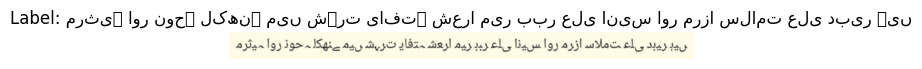

Original label      : مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ببر علی انیس اور مرزا سلامت علی دبیر ہیں
Decoded from tensor  : مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ببر علی انیس اور مرزا سلامت علی دبیر ہیں
Match: True


In [16]:
# Extra visual sanity check: display the first image with its Urdu label as the title,
# and confirm the tokenized label can be decoded back into readable Urdu text.
first_row = labels_df.iloc[0]
image_to_show = Image.open(first_row['resolved_path']).convert('RGB')

decoded_text = urdu_tokenizer.decode(sample['labels'].tolist())

plt.figure(figsize=(6, 3))
plt.imshow(image_to_show)
plt.title(f"Label: {first_row['text']}")
plt.axis('off')
plt.show()

print('Original label      :', first_row['text'])
print('Decoded from tensor  :', decoded_text)
print('Match:', first_row['text'].strip() == decoded_text.strip())

---
## Step 3 — Recreate the Train/Test Split

Unchanged — reuses the existing `split` column (from Week 1 (v2)/Step 1c above)
rather than generating a new random split, so results stay consistent with the
earlier analysis.

In [17]:
train_indices = labels_df[labels_df['split'] == 'train'].index.tolist()
test_indices = labels_df[labels_df['split'] == 'test'].index.tolist()

train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

print(f'Training samples: {len(train_dataset)}')
print(f'Testing samples : {len(test_dataset)}')
print(f'Total           : {len(train_dataset) + len(test_dataset)} (should match dataset size above)')

Training samples: 2502
Testing samples : 626
Total           : 3128 (should match dataset size above)


### Check for Train/Test Leakage

If the same image file or the exact same text label appears in both splits,
the reported test accuracy will be inflated because the model may have
partially memorized that sample during training. This check confirms the
split is clean before it is used for evaluation.

In [18]:
train_paths = set(labels_df.loc[train_indices, 'resolved_path'])
test_paths = set(labels_df.loc[test_indices, 'resolved_path'])
path_overlap = train_paths & test_paths

train_texts = set(labels_df.loc[train_indices, 'text'])
test_texts = set(labels_df.loc[test_indices, 'text'])
text_overlap = train_texts & test_texts

print(f'Image files appearing in both train and test: {len(path_overlap)}')
print(f'Exact text labels appearing in both train and test: {len(text_overlap)}')

if path_overlap:
    print('\nWarning: duplicate image files found across splits — investigate before training.')
if text_overlap:
    print(f'\nNote: {len(text_overlap)} identical text label(s) appear in both splits '
          '(different images with the same caption is expected and fine; identical images is not).')

Image files appearing in both train and test: 0
Exact text labels appearing in both train and test: 382

Note: 382 identical text label(s) appear in both splits (different images with the same caption is expected and fine; identical images is not).


---
## Step 4 — Build the `DataLoader`

Unchanged in logic — batching, shuffling (train only), and multi-worker loading.

In [19]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(train_loader))

print('Batch pixel_values shape:', batch['pixel_values'].shape)
print('Batch labels shape:', batch['labels'].shape)
print(f'\nNumber of training batches per epoch: {len(train_loader)}')
print(f'Number of testing batches per epoch : {len(test_loader)}')
print('\nDataLoader is working correctly! This project is ready for Week 4 (v2) model training.')

Batch pixel_values shape: torch.Size([8, 3, 384, 384])
Batch labels shape: torch.Size([8, 300])

Number of training batches per epoch: 313
Number of testing batches per epoch : 79

DataLoader is working correctly! This project is ready for Week 4 (v2) model training.


---
## Summary

| Step | What was done | Result |
|---|---|---|
| Step 1 | Verified dataset size against the 1,000-image target | Requirement met (dataset now well over 200, targeting 1,000+) |
| Step 1b | Resolved every image path, dropped any that could not be found | Clean, verified dataset ready for loading |
| Step 1c | Detected and fixed rows with a missing `split` value | Every image now has a `train` or `test` label |
| Step 2 | Built a **custom `UrduCharTokenizer`** (replacing TrOCR's English tokenizer) and `UrduOCRDataset` with training-only augmentation | Loads image + label pairs correctly, with proper Urdu character tokens |
| Step 3 | Reused the (now-corrected) train/test split | Train/test counts add up to the full dataset size |
| Step 4 | Built `DataLoader` objects for both splits | Batching + shuffling confirmed working |

This notebook produces everything (`train_loader`, `test_loader`, `urdu_tokenizer`)
needed for Week 4 (v2) model fine-tuning — with the tokenizer and augmentation fixes
that directly target this project's generalization problem.